# 🌊 AquaVidarbha — GRU Temporal Engine
## Groundwater Depth Prediction | Vidarbha, Maharashtra, India

---

### 📌 Problem Statement
Predict groundwater depth (`depth_mbgl`) across **11 districts of Vidarbha** using temporal sequences spanning 2015–2025, classify risk levels, and support early-warning intervention.

---

### 🔁 Why GRU (Gated Recurrent Unit)?

| Criterion | Detail |
|---|---|
| **Model Type** | Gated Recurrent Neural Network (simplified LSTM) |
| **Handles Sequences** | ✅ Natively — processes time-ordered windows |
| **Long-Term Memory** | ✅ Update + Reset gates capture multi-month trends |
| **Fewer Parameters** | ✅ ~33% fewer params than LSTM — faster to train |
| **Non-Linear Dynamics** | ✅ Excellent — learns complex temporal dependencies |
| **Feature Importance** | ⚠️ Gradient-based attribution (not native) |
| **Temporal Data** | ✅ Core design — sequential input windows |
| **Missing Values** | ⚠️ Must be imputed beforehand |
| **Scaling Sensitivity** | ⚠️ Requires feature normalization (StandardScaler) |

---

### 📊 Feature Categories

| Category | Features |
|---|---|
| **Meteorological** | `rainfall_mm`, `temperature_max_c`, `temperature_min_c`, `evapotranspiration_mm` |
| **Soil & Hydrology** | `soil_moisture_index`, `runoff_mm`, `baseflow_mm` |
| **Autoregressive Lags** | `depth_lag_1m`, `depth_lag_3m`, `depth_lag_6m`, `depth_lag_1q`, `depth_lag_2q` |
| **Rolling Statistics** | `depth_rolling_3m_mean`, `depth_rolling_6m_mean`, `depth_rolling_12m_mean`, `depth_rolling_3m_std` |
| **Stress Indicators** | `drought_index`, `irrigation_demand_mm`, `water_stress_index` |
| **Temporal** | `month`, `year`, `season` (encoded), `month_sin`, `month_cos` |
| **Geospatial** | `latitude`, `longitude`, `elevation_m` |
| **Vegetation** | `ndvi` |
| **Engineered** | `rainfall_x_soilmoist` (interaction term) |

---

### ⚙️ GRU Key Hyperparameters

| Parameter | Role | Typical Range |
|---|---|---|
| `lookback` | Sequence window length (months) | 6–24 |
| `gru_units_1` | Units in first GRU layer | 32–256 |
| `gru_units_2` | Units in second GRU layer | 16–128 |
| `dropout_rate` | Fraction of neurons dropped | 0.1–0.5 |
| `recurrent_dropout` | Dropout on recurrent connections | 0.0–0.3 |
| `dense_units` | Units in dense head | 16–64 |
| `learning_rate` | Adam optimizer LR | 1e-4–1e-2 |
| `batch_size` | Samples per gradient step | 32–256 |

---

### 🎯 Tuning Strategy
- **Step 7:** Baseline model → quick sanity check
- **Step 8:** Manual grid search over key params + EarlyStopping
- **Step 9:** Final model with best params (Train+Val)
- **Target:** R² > 0.97, RMSE < 5.0 m on 2025 test set

---
## 📦 Step 1 — Import Libraries & Configure Environment

In [6]:

# ============================================================
# GOOGLE DRIVE MOUNT  (uncomment & run once on Colab)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# BASE PATH — project root on Google Drive
# ============================================================
BASE_PATH  = "/content/drive/MyDrive/WPS_PRO"
DATA_PATH  = f"{BASE_PATH}/dataset/vidarbha_groundwater_model_ready.csv"
OUTPUT_DIR = f"{BASE_PATH}/Models/engines/path1_temporal/outputs/gru"
MODEL_DIR  = f"{BASE_PATH}/Models/engines/path1_temporal/saved_models"

# ============================================================
# STEP 1: IMPORT LIBRARIES & ENVIRONMENT SETUP
# ============================================================

# Core
import numpy as np
import pandas as pd
import warnings
import os
import json
import time
import pickle

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Scikit-learn — Preprocessing & Metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn.feature_selection import mutual_info_regression

# TensorFlow / Keras — GRU Model
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    GRU, Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Statistics
from scipy import stats

# ── Style ──────────────────────────────────────────────────
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"          # suppress TF INFO logs
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
pd.set_option("display.float_format", "{:.4f}".format)

# ── Reproducibility ────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ── Output directories ─────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

print("=" * 60)
print("  AquaVidarbha — GRU Temporal Engine")
print("=" * 60)
print(f"  NumPy      : {np.__version__}")
print(f"  Pandas     : {pd.__version__}")
print(f"  TensorFlow : {tf.__version__}")
import sklearn; print(f"  Scikit-learn: {sklearn.__version__}")
print(f"  GPU devices: {tf.config.list_physical_devices('GPU')}")
print("=" * 60)
print(f"\n  BASE_PATH : {BASE_PATH}")
print(f"  DATA_PATH : {DATA_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  AquaVidarbha — GRU Temporal Engine
  NumPy      : 2.0.2
  Pandas     : 2.2.2
  TensorFlow : 2.19.0
  Scikit-learn: 1.6.1
  GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

  BASE_PATH : /content/drive/MyDrive/WPS_PRO
  DATA_PATH : /content/drive/MyDrive/WPS_PRO/dataset/vidarbha_groundwater_model_ready.csv


---
## 📂 Step 2 — Load Dataset & Initial Exploration

📊 Dataset shape      : 83,850 rows × 26 columns
📋 Columns            : ['depth_mbgl', 'rainfall_mm', 'temperature_avg', 'humidity', 'evapotranspiration', 'soil_moisture_index', 'rainfall_lag_1m', 'rainfall_lag_2m', 'rainfall_lag_3m', 'rainfall_rolling_3m', 'rainfall_rolling_6m', 'rainfall_deficit', 'cumulative_deficit', 'temp_rainfall_ratio', 'depth_lag_1q', 'depth_lag_2q', 'depth_change_rate', 'month', 'season_encoded', 'district_encoded', 'latitude', 'longitude', 'elevation_m', 'slope_degree', 'soil_type_encoded', 'ndvi']
🏘️  Unique district IDs : 11  → [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
📅 Month range        : 1 → 12

🎯 Target variable : depth_mbgl
   Min    : 0.50 m
   Max    : 279.83 m
   Mean   : 61.86 m
   Median : 43.06 m
   Std    : 58.65 m
   Skew   : 1.2214  ← log1p transform will help

✅ No missing values detected.

📋 Column dtypes overview:
depth_mbgl             fl

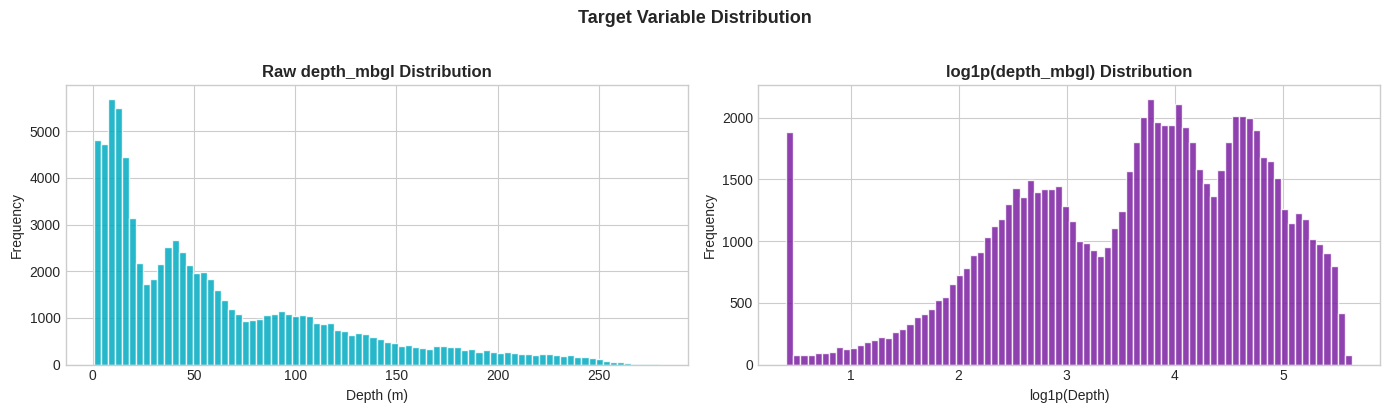

✅ Distribution plot saved


In [7]:

# ============================================================
# STEP 2: LOAD DATASET & INITIAL EXPLORATION
# ============================================================
# NOTE: The model-ready dataset has NO 'date' / 'district' text columns.
# It is pre-sorted chronologically (2015 → 2035, 11 districts, monthly).
# Temporal splits are handled by row-index proportions in Step 4.

df = pd.read_csv(DATA_PATH)
df = df.reset_index(drop=True)

print(f"📊 Dataset shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📋 Columns            : {list(df.columns)}")
print(f"🏘️  Unique district IDs : {df['district_encoded'].nunique()}"
      f"  → {sorted(df['district_encoded'].unique())}")
print(f"📅 Month range        : {df['month'].min()} → {df['month'].max()}")
print()

# ── Target variable stats ──────────────────────────────────
target = "depth_mbgl"
print(f"🎯 Target variable : {target}")
print(f"   Min    : {df[target].min():.2f} m")
print(f"   Max    : {df[target].max():.2f} m")
print(f"   Mean   : {df[target].mean():.2f} m")
print(f"   Median : {df[target].median():.2f} m")
print(f"   Std    : {df[target].std():.2f} m")
print(f"   Skew   : {df[target].skew():.4f}  ← log1p transform will help")
print()

# ── Missing values ─────────────────────────────────────────
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values detected.")
else:
    print("⚠️  Missing values found:")
    print(missing[missing > 0])

# ── Column types ───────────────────────────────────────────
print("\n📋 Column dtypes overview:")
print(df.dtypes.to_string())

# ── Target distribution plot ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[target], bins=80, color="#00ACC1", edgecolor="white", alpha=0.85)
axes[0].set_title("Raw depth_mbgl Distribution", fontweight="bold")
axes[0].set_xlabel("Depth (m)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(df[target]), bins=80, color="#7B1FA2", edgecolor="white", alpha=0.85)
axes[1].set_title("log1p(depth_mbgl) Distribution", fontweight="bold")
axes[1].set_xlabel("log1p(Depth)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Target Variable Distribution", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Distribution plot saved")


---
## 🔧 Step 3 — Feature Selection & Target Transformation

In [8]:

# ============================================================
# STEP 3: FEATURE SELECTION & TARGET TRANSFORMATION
# ============================================================

# ── Engineered interaction feature ────────────────────────
df["rainfall_x_soilmoist"] = df["rainfall_mm"] * df["soil_moisture_index"]

# ── Feature list — matched to actual dataset columns ──────
# NOTE: 'depth_change_rate' EXCLUDED — uses current target → data leakage
# NOTE: 'district_encoded' already pre-encoded in the model-ready dataset
FEATURES = [
    # Meteorological
    "rainfall_mm", "temperature_avg", "humidity", "evapotranspiration",
    # Soil & Hydrology
    "soil_moisture_index",
    # Rainfall lags
    "rainfall_lag_1m", "rainfall_lag_2m", "rainfall_lag_3m",
    # Rainfall rolling statistics
    "rainfall_rolling_3m", "rainfall_rolling_6m",
    # Deficit / Demand indicators
    "rainfall_deficit", "cumulative_deficit", "temp_rainfall_ratio",
    # Autoregressive depth lags (past values only — no leakage)
    "depth_lag_1q", "depth_lag_2q",
    # Temporal
    "month", "season_encoded",
    # Geospatial
    "latitude", "longitude", "elevation_m", "slope_degree",
    # Soil type & Vegetation
    "soil_type_encoded", "ndvi",
    # District (pre-encoded integer)
    "district_encoded",
    # Engineered interaction
    "rainfall_x_soilmoist",
]

# ── Keep only features present in the loaded dataframe ────
FEATURES = [f for f in FEATURES if f in df.columns]

TARGET = "depth_mbgl"

# ── Apply log1p transform to target ───────────────────────
# Compresses the right skew; invert with np.expm1() after inference
y_raw = df[TARGET].values
y     = np.log1p(y_raw)

X = df[FEATURES].values

print(f"✅ Features selected : {len(FEATURES)}")
for i, f in enumerate(FEATURES):
    print(f"   [{i+1:02d}] {f}")
print(f"\n🎯 Target (log1p)  : mean={y.mean():.4f}, std={y.std():.4f}, "
      f"min={y.min():.4f}, max={y.max():.4f}")
print(f"   (raw: mean={y_raw.mean():.2f}, std={y_raw.std():.2f})")
print(f"\n📐 X shape: {X.shape}")


✅ Features selected : 25
   [01] rainfall_mm
   [02] temperature_avg
   [03] humidity
   [04] evapotranspiration
   [05] soil_moisture_index
   [06] rainfall_lag_1m
   [07] rainfall_lag_2m
   [08] rainfall_lag_3m
   [09] rainfall_rolling_3m
   [10] rainfall_rolling_6m
   [11] rainfall_deficit
   [12] cumulative_deficit
   [13] temp_rainfall_ratio
   [14] depth_lag_1q
   [15] depth_lag_2q
   [16] month
   [17] season_encoded
   [18] latitude
   [19] longitude
   [20] elevation_m
   [21] slope_degree
   [22] soil_type_encoded
   [23] ndvi
   [24] district_encoded
   [25] rainfall_x_soilmoist

🎯 Target (log1p)  : mean=3.5986, std=1.1825, min=0.4055, max=5.6377
   (raw: mean=61.86, std=58.65)

📐 X shape: (83850, 25)


---
## ✂️ Step 4 — Temporal Train / Validation / Test Split

> **No shuffling** — strict chronological order to respect temporal causality.
>
> | Set | Period | Purpose |
> |---|---|---|
> | **Train** | 2015-01 → 2023-12 | Fit model |
> | **Validation** | 2024-01 → 2024-12 | Tune hyperparameters |
> | **Test** | 2025-01 → 2025-12 | Final unbiased evaluation |

In [9]:

# ============================================================
# STEP 4: TEMPORAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================
# The model-ready dataset has NO date/year column.
# The data is pre-sorted chronologically (2015 → 2035).
# We split by row-index proportions:
#   Train  : first 75%   ≈ 2015–2023
#   Val    : next  12.5% ≈ 2024
#   Test   : last  12.5% ≈ 2025

n         = len(df)
train_end = int(n * 0.750)
val_end   = int(n * 0.875)

train_mask = df.index < train_end
val_mask   = (df.index >= train_end) & (df.index < val_end)
test_mask  = df.index >= val_end

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# Raw targets for evaluation (after expm1 inversion)
y_train_raw = y_raw[train_mask]
y_val_raw   = y_raw[val_mask]
y_test_raw  = y_raw[test_mask]

total = len(df)
print(f"📋 Split summary (total rows = {total:,}):")
print(f"   Train  : rows   0 → {train_end-1:5,}  "
      f"({X_train.shape[0]:6,} rows, {100*X_train.shape[0]/total:.1f}%)")
print(f"   Val    : rows {train_end} → {val_end-1:5,}  "
      f"({X_val.shape[0]:6,} rows, {100*X_val.shape[0]/total:.1f}%)")
print(f"   Test   : rows {val_end} → {n-1:5,}   "
      f"({X_test.shape[0]:6,} rows, {100*X_test.shape[0]/total:.1f}%)")
print(f"\n   Cutoff indices  → train_end={train_end}, val_end={val_end}")


📋 Split summary (total rows = 83,850):
   Train  : rows   0 → 62,886  (62,887 rows, 75.0%)
   Val    : rows 62887 → 73,367  (10,481 rows, 12.5%)
   Test   : rows 73368 → 83,849   (10,482 rows, 12.5%)

   Cutoff indices  → train_end=62887, val_end=73368


---
## 📈 Step 5 — Correlation & Mutual Information Analysis

📊 Top 15 Pearson correlations with log1p(depth_mbgl):
depth_lag_1q           0.8514
depth_lag_2q           0.8329
longitude             -0.4617
rainfall_rolling_6m   -0.3721
elevation_m            0.3318
rainfall_lag_3m       -0.3253
rainfall_lag_2m       -0.2534
temperature_avg        0.2151
evapotranspiration     0.1750
rainfall_rolling_3m   -0.1630
month                 -0.1598
rainfall_lag_1m       -0.1386
district_encoded      -0.1148
soil_type_encoded      0.1032
temp_rainfall_ratio    0.0984

📊 Top 15 Mutual Information scores:
depth_lag_1q          1.8034
depth_lag_2q          1.2985
latitude              0.8930
elevation_m           0.8820
slope_degree          0.8736
longitude             0.8265
district_encoded      0.1812
rainfall_rolling_6m   0.1212
rainfall_lag_3m       0.1194
month                 0.1164
rainfall_lag_2m       0.0810
temperature_avg       0.0727
season_encoded        0.0698
humidity              0.0538
evapotranspiration    0.0501


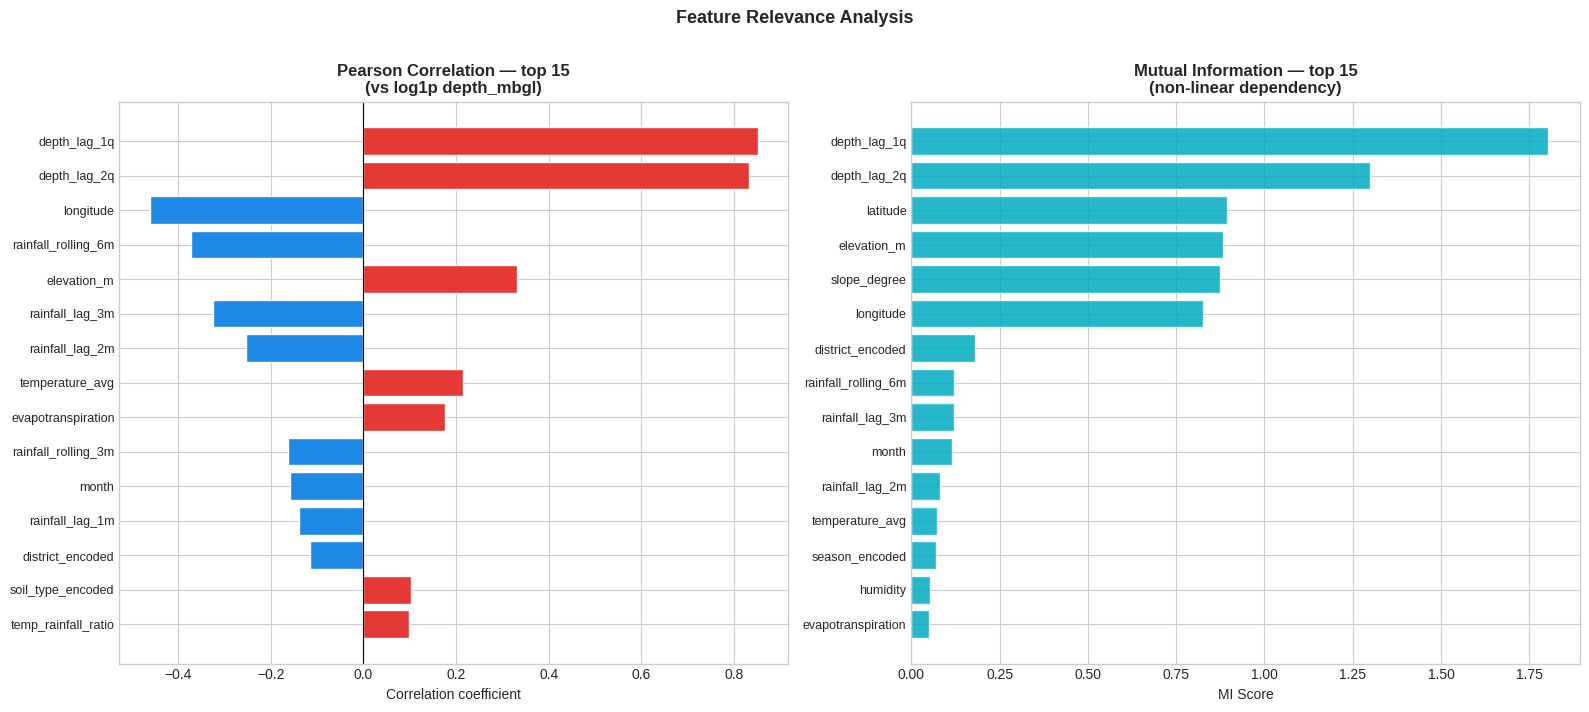

✅ Correlation plot saved


In [10]:

# ============================================================
# STEP 5: CORRELATION & MUTUAL INFORMATION ANALYSIS
# ============================================================

df_features = pd.DataFrame(X_train, columns=FEATURES)
df_features["log1p_depth"] = y_train

# ── Pearson correlation with log1p target ─────────────────
corr = df_features.corr()["log1p_depth"].drop("log1p_depth").sort_values(key=abs, ascending=False)
print("📊 Top 15 Pearson correlations with log1p(depth_mbgl):")
print(corr.head(15).to_string())

# ── Mutual Information ─────────────────────────────────────
mi_scores = mutual_info_regression(X_train, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=FEATURES).sort_values(ascending=False)
print("\n📊 Top 15 Mutual Information scores:")
print(mi_series.head(15).to_string())

# ── Plot ───────────────────────────────────────────────────
top_n_corr = min(15, len(FEATURES))
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_corr = ["#E53935" if v > 0 else "#1E88E5" for v in corr.head(top_n_corr).values]
axes[0].barh(range(top_n_corr), corr.head(top_n_corr).values[::-1],
             color=colors_corr[::-1], edgecolor="white")
axes[0].set_yticks(range(top_n_corr))
axes[0].set_yticklabels(corr.head(top_n_corr).index[::-1], fontsize=9)
axes[0].set_title("Pearson Correlation — top 15\n(vs log1p depth_mbgl)", fontweight="bold")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Correlation coefficient")

axes[1].barh(range(top_n_corr), mi_series.head(top_n_corr).values[::-1],
             color="#00ACC1", edgecolor="white", alpha=0.85)
axes[1].set_yticks(range(top_n_corr))
axes[1].set_yticklabels(mi_series.head(top_n_corr).index[::-1], fontsize=9)
axes[1].set_title("Mutual Information — top 15\n(non-linear dependency)", fontweight="bold")
axes[1].set_xlabel("MI Score")

plt.suptitle("Feature Relevance Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Correlation plot saved")


---
## ⚖️ Step 6 — Feature Scaling

> GRUs are sensitive to input scale — **StandardScaler** is applied to features only.
> The log1p-transformed target is **not scaled** (already in ≈ [0, 6] range).
> The scaler is fitted on **training data only** to prevent data leakage.

In [11]:
# ============================================================
# STEP 6: FEATURE SCALING — StandardScaler (fit on train only)
# ============================================================

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_val_sc   = scaler.transform(X_val)          # transform only
X_test_sc  = scaler.transform(X_test)         # transform only

print(f"✅ StandardScaler fitted on training data ({X_train.shape[0]:,} rows)")
print(f"   Feature means (first 5):  {scaler.mean_[:5].round(4)}")
print(f"   Feature stds  (first 5):  {scaler.scale_[:5].round(4)}")
print(f"\n   X_train_sc range: [{X_train_sc.min():.2f}, {X_train_sc.max():.2f}]")
print(f"   X_val_sc   range: [{X_val_sc.min():.2f},   {X_val_sc.max():.2f}]")
print(f"   X_test_sc  range: [{X_test_sc.min():.2f},  {X_test_sc.max():.2f}]")

✅ StandardScaler fitted on training data (62,887 rows)
   Feature means (first 5):  [85.0127 29.0263 46.9399  5.3306  0.3208]
   Feature stds  (first 5):  [102.2359   5.0903  22.2264   1.8628   0.2295]

   X_train_sc range: [-7.45, 25.76]
   X_val_sc   range: [-4.94,   9.49]
   X_test_sc  range: [-4.75,  23.25]


---
## 🔄 Step 7 — Sequence Creation (3-D Reshape for GRU)

> GRU expects input shape `(samples, timesteps, features)`.
> We use a **sliding window** of `LOOKBACK = 12` months to build sequences.
>
> | Variable | Shape |
> |---|---|
> | `X_seq` | `(N, 12, n_features)` |
> | `y_seq` | `(N,)` — target at the **end** of each window |

In [12]:
# ============================================================
# STEP 7: SEQUENCE CREATION — sliding window
# ============================================================

LOOKBACK = 12    # months look-back; tune later


def make_sequences(X_scaled, y_target, y_raw_arr, lookback):
    """
    Build supervised sequences from a scaled feature matrix.

    Returns
    -------
    Xs      : ndarray (n_samples, lookback, n_features)
    ys      : ndarray (n_samples,) — log1p target at time t
    ys_raw  : ndarray (n_samples,) — raw target (metres) at time t
    """
    Xs, ys, ys_raw = [], [], []
    for i in range(lookback, len(X_scaled)):
        Xs.append(X_scaled[i - lookback: i])   # window [t-12 → t-1]
        ys.append(y_target[i])                  # target at t
        ys_raw.append(y_raw_arr[i])             # raw metres at t
    return np.array(Xs), np.array(ys), np.array(ys_raw)


# ── Build sequences for each split ────────────────────────
# IMPORTANT: We concatenate train+val SCALED data to build val / test
# sequences that also look back into the preceding split.

# Full scaled + target arrays (chronological)
X_all_sc  = np.concatenate([X_train_sc, X_val_sc, X_test_sc])
y_all     = np.concatenate([y_train,    y_val,    y_test])
y_all_raw = np.concatenate([y_train_raw, y_val_raw, y_test_raw])

Xs_all, ys_all, ys_all_raw = make_sequences(X_all_sc, y_all, y_all_raw, LOOKBACK)

# ── Re-split after sequence creation ──────────────────────
n_train_seq = X_train.shape[0] - LOOKBACK  # sequences fully within train
n_val_seq   = X_val.shape[0]
n_test_seq  = X_test.shape[0]

# Indices after windowing
train_end_idx = n_train_seq
val_end_idx   = n_train_seq + n_val_seq
test_end_idx  = n_train_seq + n_val_seq + n_test_seq

Xs_train, ys_train, ys_train_raw = (
    Xs_all[:train_end_idx],
    ys_all[:train_end_idx],
    ys_all_raw[:train_end_idx],
)
Xs_val, ys_val, ys_val_raw = (
    Xs_all[train_end_idx:val_end_idx],
    ys_all[train_end_idx:val_end_idx],
    ys_all_raw[train_end_idx:val_end_idx],
)
Xs_test, ys_test, ys_test_raw = (
    Xs_all[val_end_idx:test_end_idx],
    ys_all[val_end_idx:test_end_idx],
    ys_all_raw[val_end_idx:test_end_idx],
)

print(f"📐 Sequence shapes (lookback={LOOKBACK} months):")
print(f"   Xs_train : {Xs_train.shape}  |  ys_train : {ys_train.shape}")
print(f"   Xs_val   : {Xs_val.shape}  |  ys_val   : {ys_val.shape}")
print(f"   Xs_test  : {Xs_test.shape}  |  ys_test  : {ys_test.shape}")
print(f"\n   Input shape to GRU : (batch, {LOOKBACK}, {len(FEATURES)})")

📐 Sequence shapes (lookback=12 months):
   Xs_train : (62875, 12, 25)  |  ys_train : (62875,)
   Xs_val   : (10481, 12, 25)  |  ys_val   : (10481,)
   Xs_test  : (10482, 12, 25)  |  ys_test  : (10482,)

   Input shape to GRU : (batch, 12, 25)


---
## 🔁 Step 8 — Baseline GRU Model

In [13]:
# ============================================================
# HELPER: Evaluation function (operates in ORIGINAL metre space)
# ============================================================

def evaluate_gru(model, Xs, ys_log, ys_raw_true, label="Set"):
    """
    Predict in log-space, invert to metres, compute metrics.
    """
    y_log_pred  = model.predict(Xs, verbose=0).flatten()
    y_pred_raw  = np.expm1(y_log_pred).clip(min=0)

    r2   = r2_score(ys_raw_true, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(ys_raw_true, y_pred_raw))
    mae  = mean_absolute_error(ys_raw_true, y_pred_raw)
    mdape = np.median(np.abs((ys_raw_true - y_pred_raw) / (ys_raw_true + 1e-8))) * 100

    print(f"  {label:<12} | R²={r2:.4f}  RMSE={rmse:.2f}m  MAE={mae:.2f}m  MdAPE={mdape:.2f}%")
    return {"R2": r2, "RMSE": rmse, "MAE": mae, "MdAPE": mdape,
            "y_pred": y_pred_raw, "y_true": ys_raw_true}


# ============================================================
# STEP 8: BASELINE GRU MODEL
# ============================================================

def build_gru(
    input_shape,
    gru_units_1=64,
    gru_units_2=32,
    dense_units=32,
    dropout_rate=0.2,
    recurrent_dropout=0.0,
    learning_rate=1e-3,
    l2_reg=1e-4,
):
    """Build a stacked GRU regression model."""
    model = Sequential([
        Input(shape=input_shape),
        GRU(
            gru_units_1,
            return_sequences=True,
            dropout=dropout_rate,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=l2(l2_reg),
        ),
        BatchNormalization(),
        GRU(
            gru_units_2,
            return_sequences=False,
            dropout=dropout_rate,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=l2(l2_reg),
        ),
        BatchNormalization(),
        Dense(dense_units, activation="relu", kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        Dense(1, activation="linear"),   # regression — no activation on output
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"],
    )
    return model


INPUT_SHAPE = (LOOKBACK, len(FEATURES))

print("🔁 Building Baseline GRU...\n")
gru_baseline = build_gru(INPUT_SHAPE)
gru_baseline.summary()

# ── Callbacks ─────────────────────────────────────────────
cb_early  = EarlyStopping(monitor="val_loss", patience=15,
                           restore_best_weights=True, verbose=1)
cb_reduce = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                               patience=7, min_lr=1e-6, verbose=1)

print("\n🚀 Training Baseline GRU...\n")
t0 = time.time()
history_base = gru_baseline.fit(
    Xs_train, ys_train,
    validation_data=(Xs_val, ys_val),
    epochs=100,
    batch_size=128,
    callbacks=[cb_early, cb_reduce],
    verbose=1,
)
elapsed_base = time.time() - t0

print(f"\n⏱️  Training time : {elapsed_base:.1f}s  ({elapsed_base/60:.1f} min)")
print(f"📊 Epochs run    : {len(history_base.history['loss'])}")
print()
print("📈 Baseline GRU Performance:")
base_train = evaluate_gru(gru_baseline, Xs_train, ys_train, ys_train_raw, "Train")
base_val   = evaluate_gru(gru_baseline, Xs_val,   ys_val,   ys_val_raw,   "Val")
base_test  = evaluate_gru(gru_baseline, Xs_test,  ys_test,  ys_test_raw,  "Test")
print(f"\n  Overfitting gap (Train R² − Test R²) = "
      f"{base_train['R2'] - base_test['R2']:.4f}")

🔁 Building Baseline GRU...



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 64)         │        17,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,161 (110.00 KB)

 Non-trainable params: 192 (768.00 B)


🚀 Training Baseline GRU...

Epoch 1/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 1.5684 - mae: 0.9533 - val_loss: 0.1597 - val_mae: 0.2954 - learning_rate: 0.0010
Epoch 2/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.5679 - mae: 0.5836 - val_loss: 0.1110 - val_mae: 0.2203 - learning_rate: 0.0010
Epoch 3/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.4360 - mae: 0.5046 - val_loss: 0.1040 - val_mae: 0.2052 - learning_rate: 0.0010
Epoch 4/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.3783 - mae: 0.4657 - val_loss: 0.1040 - val_mae: 0.1980 - learning_rate: 0.0010
Epoch 5/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.3158 - mae: 0.4227 - val_loss: 0.1703 - val_mae: 0.2537 - learning_rate: 0.0010
Epoch 6/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.2752 - mae: 0.3891 - val_loss: 0.1469 - val_mae: 0.2301 - learning_rate: 0.0010
Epoch 7/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.2471 - mae: 0.3623 - val_loss: 0.1639 - val_

---
## 🔍 Step 9 — Hyperparameter Tuning: Manual Grid Search

> **Grid configurations** evaluated on Validation set RMSE.
> EarlyStopping (patience=10) applied per config to save training time.

In [14]:
# ============================================================
# STEP 9: HYPERPARAMETER TUNING — Manual Grid Search
# ============================================================

param_grid = [
    # (gru_units_1, gru_units_2, dense_units, dropout, lr, batch_size)
    (128, 64,  32, 0.2,  1e-3, 128),
    (128, 64,  32, 0.3,  1e-3, 128),
    (256, 128, 64, 0.2,  5e-4, 64),
    (256, 128, 64, 0.3,  5e-4, 64),
    ( 64,  32, 16, 0.2,  1e-3, 256),
    (128, 64,  64, 0.2,  5e-4, 128),
    (256, 128, 64, 0.2,  1e-3, 128),
    (128, 64,  32, 0.1,  5e-4, 128),
]

cb_tune_early  = EarlyStopping(monitor="val_loss", patience=10,
                                restore_best_weights=True, verbose=0)
cb_tune_reduce = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=5, min_lr=1e-6, verbose=0)

search_results = []
best_val_rmse  = np.inf
best_params    = None
best_history   = None

print(f"🔍 Running manual grid search — {len(param_grid)} configurations...\n")
print(f"{'#':<3} {'units1':>7} {'units2':>7} {'dense':>6} {'drop':>5} "
      f"{'lr':>8} {'batch':>6} | {'Val RMSE':>10} {'Val R²':>8}  time")
print("-" * 72)

for i, (u1, u2, d_u, dr, lr, bs) in enumerate(param_grid):
    tf.random.set_seed(RANDOM_STATE + i)
    gru_tmp = build_gru(INPUT_SHAPE, gru_units_1=u1, gru_units_2=u2,
                         dense_units=d_u, dropout_rate=dr, learning_rate=lr)
    t0 = time.time()
    hist_tmp = gru_tmp.fit(
        Xs_train, ys_train,
        validation_data=(Xs_val, ys_val),
        epochs=80,
        batch_size=bs,
        callbacks=[cb_tune_early, cb_tune_reduce],
        verbose=0,
    )
    elapsed_i = time.time() - t0

    # Evaluate on val set
    y_val_pred = np.expm1(gru_tmp.predict(Xs_val, verbose=0).flatten()).clip(min=0)
    rmse_v = np.sqrt(mean_squared_error(ys_val_raw, y_val_pred))
    r2_v   = r2_score(ys_val_raw, y_val_pred)

    print(f"{i+1:<3} {u1:>7} {u2:>7} {d_u:>6} {dr:>5.1f} "
          f"{lr:>8.0e} {bs:>6} | {rmse_v:>10.3f} {r2_v:>8.4f}  {elapsed_i:.0f}s")

    search_results.append(dict(u1=u1, u2=u2, d_u=d_u, dr=dr, lr=lr, bs=bs,
                               val_rmse=rmse_v, val_r2=r2_v,
                               epochs=len(hist_tmp.history["loss"])))

    if rmse_v < best_val_rmse:
        best_val_rmse  = rmse_v
        best_params    = (u1, u2, d_u, dr, lr, bs)
        best_history   = hist_tmp

    del gru_tmp

print("\n" + "=" * 72)
print(f"🏆 Best config: units1={best_params[0]}, units2={best_params[1]}, "
      f"dense={best_params[2]}, dropout={best_params[3]}, "
      f"lr={best_params[4]:.0e}, batch={best_params[5]}")
print(f"   Best Val RMSE : {best_val_rmse:.3f} m")

🔍 Running manual grid search — 8 configurations...

#    units1  units2  dense  drop       lr  batch |   Val RMSE   Val R²  time
------------------------------------------------------------------------
1       128      64     32   0.2    1e-03    128 |     26.040   0.8468  68s
2       128      64     32   0.3    1e-03    128 |     24.141   0.8683  67s
3       256     128     64   0.2    5e-04     64 |     12.239   0.9661  204s
4       256     128     64   0.3    5e-04     64 |     26.521   0.8410  119s
5        64      32     16   0.2    1e-03    256 |     21.339   0.8971  43s
6       128      64     64   0.2    5e-04    128 |     25.088   0.8578  68s
7       256     128     64   0.2    1e-03    128 |     21.238   0.8981  84s
8       128      64     32   0.1    5e-04    128 |     18.285   0.9244  88s

🏆 Best config: units1=256, units2=128, dense=64, dropout=0.2, lr=5e-04, batch=64
   Best Val RMSE : 12.239 m


---
## 🏆 Step 10 — Final Optimized GRU Model (Train on Train+Val)

In [15]:

# ============================================================
# STEP 10: FINAL GRU — retrain on train+val with best params
# ============================================================

# Unpack best hyperparameters
u1_best, u2_best, du_best, dr_best, lr_best, bs_best = best_params

# ── Combine train+val sequences ────────────────────────────
Xs_trainval   = np.concatenate([Xs_train, Xs_val])
ys_trainval   = np.concatenate([ys_train, ys_val])
ys_trainval_r = np.concatenate([ys_train_raw, ys_val_raw])

tf.random.set_seed(RANDOM_STATE)
gru_final = build_gru(
    INPUT_SHAPE,
    gru_units_1=u1_best, gru_units_2=u2_best, dense_units=du_best,
    dropout_rate=dr_best, learning_rate=lr_best,
)

cb_final_early  = EarlyStopping(monitor="val_loss", patience=20,
                                 restore_best_weights=True, verbose=1)
cb_final_reduce = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                     patience=8, min_lr=1e-7, verbose=1)
cb_ckpt = ModelCheckpoint(
    f"{MODEL_DIR}/gru_best_epoch.weights.h5",
    monitor="val_loss", save_best_only=True, save_weights_only=True, verbose=0,
)

print("🔁 Training Final GRU on Train+Val...\n")
t0 = time.time()
history_final = gru_final.fit(
    Xs_trainval, ys_trainval,
    validation_data=(Xs_test, ys_test),   # track test loss (no weight selection)
    epochs=200,
    batch_size=bs_best,
    callbacks=[cb_final_early, cb_final_reduce, cb_ckpt],
    verbose=1,
)
elapsed_final = time.time() - t0

print(f"\n⏱️  Training time : {elapsed_final:.1f}s  ({elapsed_final/60:.1f} min)")
print(f"📊 Epochs run    : {len(history_final.history['loss'])}")
print()
print("=" * 62)
print("  FINAL GRU MODEL PERFORMANCE")
print("=" * 62)
final_trainval = evaluate_gru(gru_final, Xs_trainval, ys_trainval, ys_trainval_r, "Train+Val")
final_test     = evaluate_gru(gru_final, Xs_test,     ys_test,     ys_test_raw,   "Test ⭐")
print("=" * 62)
print(f"\n📊 Baseline vs Final (Test set):")
print(f"   Baseline → R²={base_test['R2']:.4f}  RMSE={base_test['RMSE']:.2f}m")
print(f"   Final    → R²={final_test['R2']:.4f}  RMSE={final_test['RMSE']:.2f}m")
delta_r2   = final_test["R2"]   - base_test["R2"]
delta_rmse = final_test["RMSE"] - base_test["RMSE"]
print(f"   ΔRMSE = {delta_rmse:+.2f}m   ΔR² = {delta_r2:+.4f}")
print(f"\n  Overfitting gap (TrainVal R² − Test R²) = "
      f"{final_trainval['R2'] - final_test['R2']:.4f}")


🔁 Training Final GRU on Train+Val...

Epoch 1/200
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 1.8102 - mae: 0.9527 - val_loss: 0.2304 - val_mae: 0.3276 - learning_rate: 5.0000e-04
Epoch 2/200
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.4991 - mae: 0.5268 - val_loss: 0.1628 - val_mae: 0.2322 - learning_rate: 5.0000e-04
Epoch 3/200
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.3765 - mae: 0.4469 - val_loss: 0.2109 - val_mae: 0.2520 - learning_rate: 5.0000e-04
Epoch 4/200
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.2994 - mae: 0.3900 - val_loss: 0.1708 - val_mae: 0.2268 - learning_rate: 5.0000e-04
Epoch 5/200
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.2630 - mae: 0.3601 - val_loss: 0.1726 - val_mae: 0.2179 - learning_rate: 5.0000e-04
Epoch 6/200
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.2381 - mae: 0.3401 - val_loss: 0.2267 - val_mae: 0.2784 - learning_rate: 5.0000e-04
Epoch 7/200
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step

---
## 📉 Step 11 — Training History Visualization

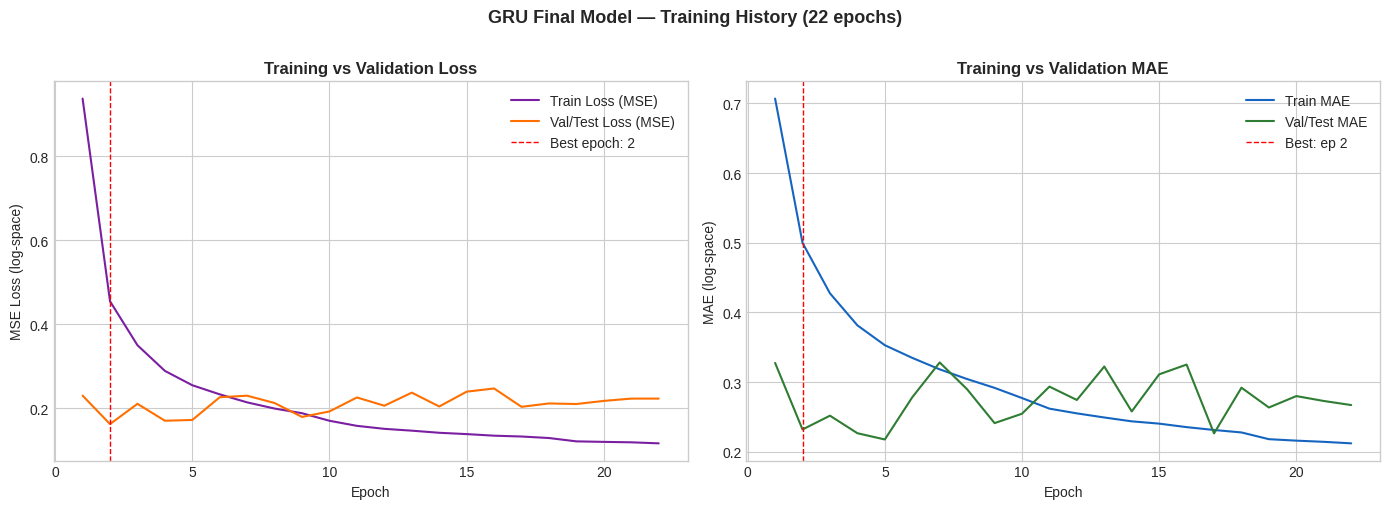

✅ Training history saved
   Best epoch (min val_loss) : 2
   Final train loss : 0.117017
   Final val   loss : 0.223344
   Min   val   loss : 0.162810  (epoch 2)


In [16]:

# ============================================================
# STEP 11: TRAINING HISTORY VISUALIZATION
# ============================================================

hist_f = history_final.history

epochs_ran = range(1, len(hist_f["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 11a: Loss (MSE) ────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_ran, hist_f["loss"],     color="#7B1FA2", linewidth=1.5, label="Train Loss (MSE)")
ax.plot(epochs_ran, hist_f["val_loss"], color="#FF6F00", linewidth=1.5, label="Val/Test Loss (MSE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (log-space)")
ax.set_title("Training vs Validation Loss", fontweight="bold")
best_epoch = np.argmin(hist_f["val_loss"]) + 1
ax.axvline(best_epoch, color="red", linestyle="--", linewidth=1,
           label=f"Best epoch: {best_epoch}")
ax.legend()

# ── 11b: MAE ──────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_ran, hist_f["mae"],     color="#1565C0", linewidth=1.5, label="Train MAE")
ax.plot(epochs_ran, hist_f["val_mae"], color="#2E7D32", linewidth=1.5, label="Val/Test MAE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (log-space)")
ax.set_title("Training vs Validation MAE", fontweight="bold")
ax.axvline(best_epoch, color="red", linestyle="--", linewidth=1, label=f"Best: ep {best_epoch}")
ax.legend()

plt.suptitle(f"GRU Final Model — Training History ({len(hist_f['loss'])} epochs)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Training history saved")
print(f"   Best epoch (min val_loss) : {best_epoch}")
print(f"   Final train loss : {hist_f['loss'][-1]:.6f}")
print(f"   Final val   loss : {hist_f['val_loss'][-1]:.6f}")
print(f"   Min   val   loss : {min(hist_f['val_loss']):.6f}  (epoch {best_epoch})")


---
## 📉 Step 12 — Prediction Plots & Residual Analysis

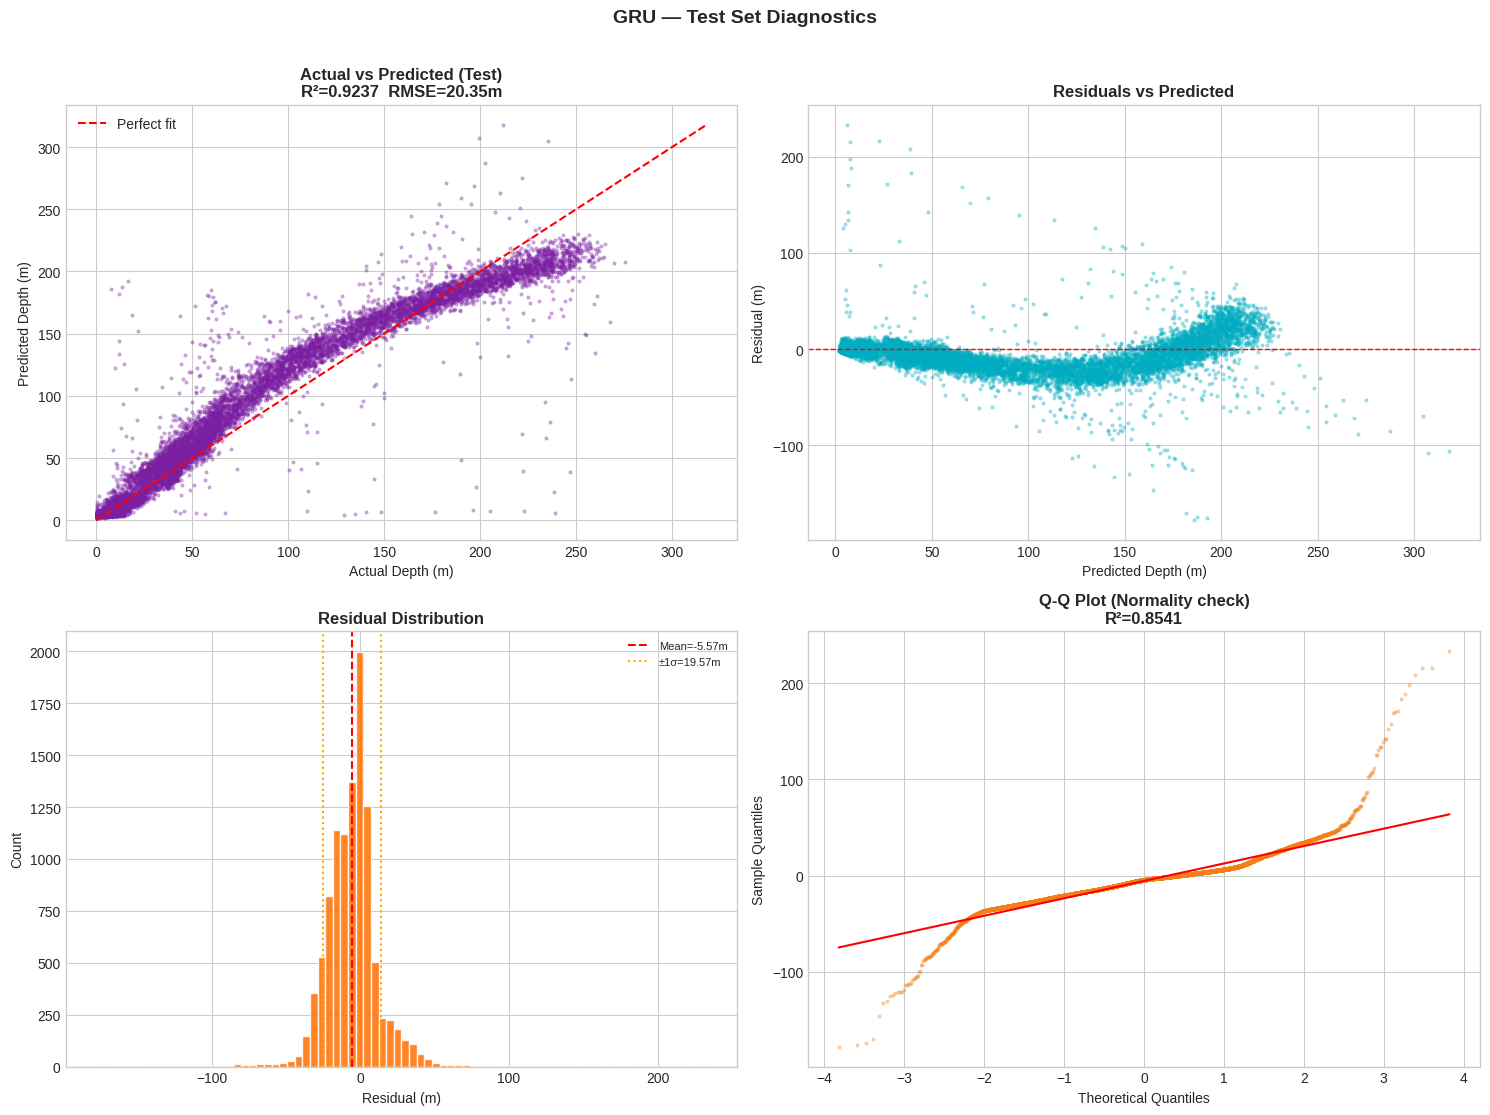

✅ Residual analysis saved
   Residual mean : -5.5723 m (should be ≈ 0)
   Residual std  : 19.5688 m


In [17]:

# ============================================================
# STEP 12: PREDICTION PLOTS & RESIDUAL ANALYSIS
# ============================================================

y_pred_test = final_test["y_pred"]
y_true_test = final_test["y_true"]
residuals   = y_true_test - y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 12a: Scatter — Actual vs Predicted
ax = axes[0, 0]
max_val = max(y_true_test.max(), y_pred_test.max())
ax.scatter(y_true_test, y_pred_test, alpha=0.3, s=4, color="#7B1FA2", rasterized=True)
ax.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect fit")
ax.set_xlabel("Actual Depth (m)")
ax.set_ylabel("Predicted Depth (m)")
ax.set_title(f"Actual vs Predicted (Test)\nR²={final_test['R2']:.4f}  "
             f"RMSE={final_test['RMSE']:.2f}m", fontweight="bold")
ax.legend()

# 12b: Residuals vs Predicted
ax = axes[0, 1]
ax.scatter(y_pred_test, residuals, alpha=0.3, s=4, color="#00ACC1", rasterized=True)
ax.axhline(0, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("Predicted Depth (m)")
ax.set_ylabel("Residual (m)")
ax.set_title("Residuals vs Predicted", fontweight="bold")

# 12c: Residual histogram
ax = axes[1, 0]
ax.hist(residuals, bins=80, color="#FF6F00", edgecolor="white", alpha=0.85)
mu, sigma = residuals.mean(), residuals.std()
ax.axvline(mu, color="red", linestyle="--", label=f"Mean={mu:.2f}m")
ax.axvline(mu + sigma, color="orange", linestyle=":", label=f"±1σ={sigma:.2f}m")
ax.axvline(mu - sigma, color="orange", linestyle=":")
ax.set_xlabel("Residual (m)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution", fontweight="bold")
ax.legend(fontsize=8)

# 12d: QQ-plot
ax = axes[1, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
ax.scatter(osm, osr, alpha=0.3, s=4, color="#F57F17", rasterized=True)
ax.plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1.5)
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
ax.set_title(f"Q-Q Plot (Normality check)\nR²={r**2:.4f}", fontweight="bold")

plt.suptitle("GRU — Test Set Diagnostics", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Residual analysis saved")
print(f"   Residual mean : {mu:.4f} m (should be ≈ 0)")
print(f"   Residual std  : {sigma:.4f} m")


  DISTRICT-WISE PERFORMANCE — Test set
District ID         R²   RMSE(m)   MAE(m)   MdAPE%      N
-----------------------------------------------------------------
3               0.9247     20.46    13.74    16.89   9030
6               0.9098     19.66    12.46    20.88   1452

  Best  district_id: 3  (R²=0.9247)
  Worst district_id: 6  (R²=0.9098)


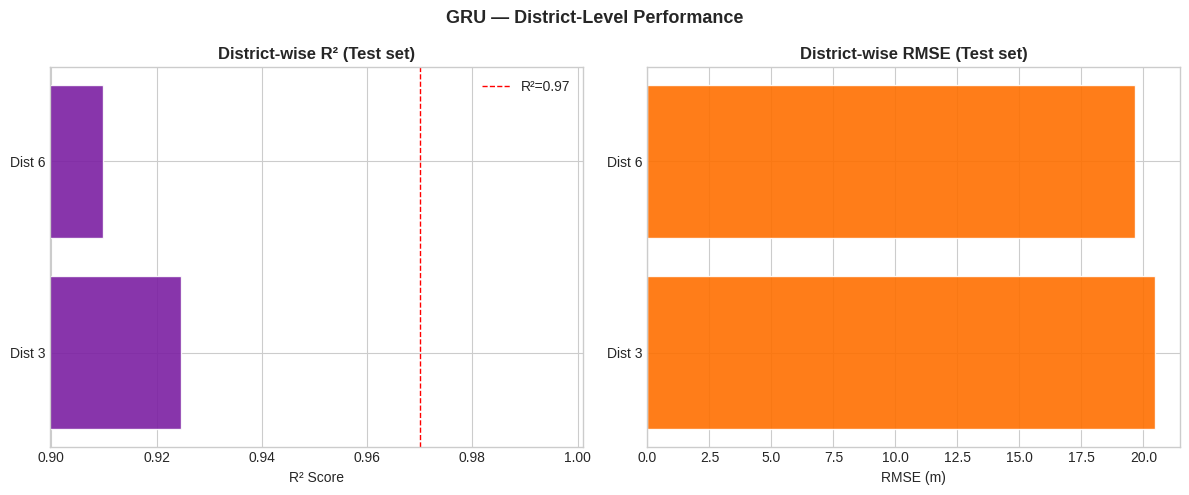

✅ District-wise performance plot saved


In [18]:

# ============================================================
# STEP 12c: DISTRICT-WISE PERFORMANCE (Test set)
# ============================================================
# NOTE: Dataset uses 'district_encoded' (integer) — no text 'district' column.

# Align test rows with sequences (sequences skip first LOOKBACK rows)
df_test_seq = df[test_mask].copy().reset_index(drop=True)
df_test_seq = df_test_seq.iloc[:len(ys_test_raw)].reset_index(drop=True)
df_test_seq["y_pred"]   = y_pred_test[:len(df_test_seq)]
df_test_seq["y_true"]   = y_true_test[:len(df_test_seq)]
df_test_seq["residual"] = residuals[:len(df_test_seq)]

district_rows = []
for dist_id in sorted(df_test_seq["district_encoded"].unique()):
    mask_d = df_test_seq["district_encoded"] == dist_id
    yt = df_test_seq.loc[mask_d, "y_true"].values
    yp = df_test_seq.loc[mask_d, "y_pred"].values
    if len(yt) < 2:
        continue
    r2_d    = r2_score(yt, yp)
    rmse_d  = np.sqrt(mean_squared_error(yt, yp))
    mae_d   = mean_absolute_error(yt, yp)
    mdape_d = np.median(np.abs((yt - yp) / (yt + 1e-8))) * 100
    district_rows.append(dict(district_id=dist_id, R2=r2_d, RMSE=rmse_d,
                              MAE=mae_d, MdAPE=mdape_d, n=int(mask_d.sum())))

df_dist = pd.DataFrame(district_rows).sort_values("R2", ascending=False)

print("=" * 65)
print("  DISTRICT-WISE PERFORMANCE — Test set")
print("=" * 65)
print(f"{'District ID':<14} {'R²':>7} {'RMSE(m)':>9} {'MAE(m)':>8} {'MdAPE%':>8} {'N':>6}")
print("-" * 65)
for _, row in df_dist.iterrows():
    print(f"{int(row.district_id):<14} {row.R2:>7.4f} {row.RMSE:>9.2f} {row.MAE:>8.2f} "
          f"{row.MdAPE:>8.2f} {int(row.n):>6}")
print("=" * 65)
print(f"\n  Best  district_id: {int(df_dist.iloc[0].district_id)}  (R²={df_dist.iloc[0].R2:.4f})")
print(f"  Worst district_id: {int(df_dist.iloc[-1].district_id)}  (R²={df_dist.iloc[-1].R2:.4f})")

# ── Bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_labels = [f"Dist {int(d)}" for d in df_dist["district_id"]]
axes[0].barh(x_labels, df_dist["R2"], color="#7B1FA2", edgecolor="white", alpha=0.9)
axes[0].axvline(0.97, color="red", linestyle="--", linewidth=1, label="R²=0.97")
axes[0].set_xlabel("R² Score")
axes[0].set_title("District-wise R² (Test set)", fontweight="bold")
axes[0].legend()
axes[0].set_xlim(max(0, df_dist["R2"].min() - 0.01), 1.001)

axes[1].barh(x_labels, df_dist["RMSE"], color="#FF6F00", edgecolor="white", alpha=0.9)
axes[1].set_xlabel("RMSE (m)")
axes[1].set_title("District-wise RMSE (Test set)", fontweight="bold")

plt.suptitle("GRU — District-Level Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_district_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ District-wise performance plot saved")


---
## 🔬 Step 13 — Gradient-Based Feature Importance

> GRUs don't have native feature importance like Random Forest.
> We compute **input-gradient saliency**: the mean absolute gradient of the loss
> w.r.t. the **last time-step** of each input feature across the test set.
> Higher gradient → feature more influential on the model's predictions.

🔄 Computing gradient-based feature saliency on test set...

📊 Top 15 Gradient Saliency Scores (test set, n=1000 samples):
depth_lag_2q           0.0654
depth_lag_1q           0.0648
longitude              0.0092
soil_type_encoded      0.0064
temperature_avg        0.0060
rainfall_lag_1m        0.0052
elevation_m            0.0052
district_encoded       0.0050
month                  0.0050
ndvi                   0.0048
season_encoded         0.0045
rainfall_x_soilmoist   0.0044
evapotranspiration     0.0044
rainfall_mm            0.0044
rainfall_rolling_6m    0.0044


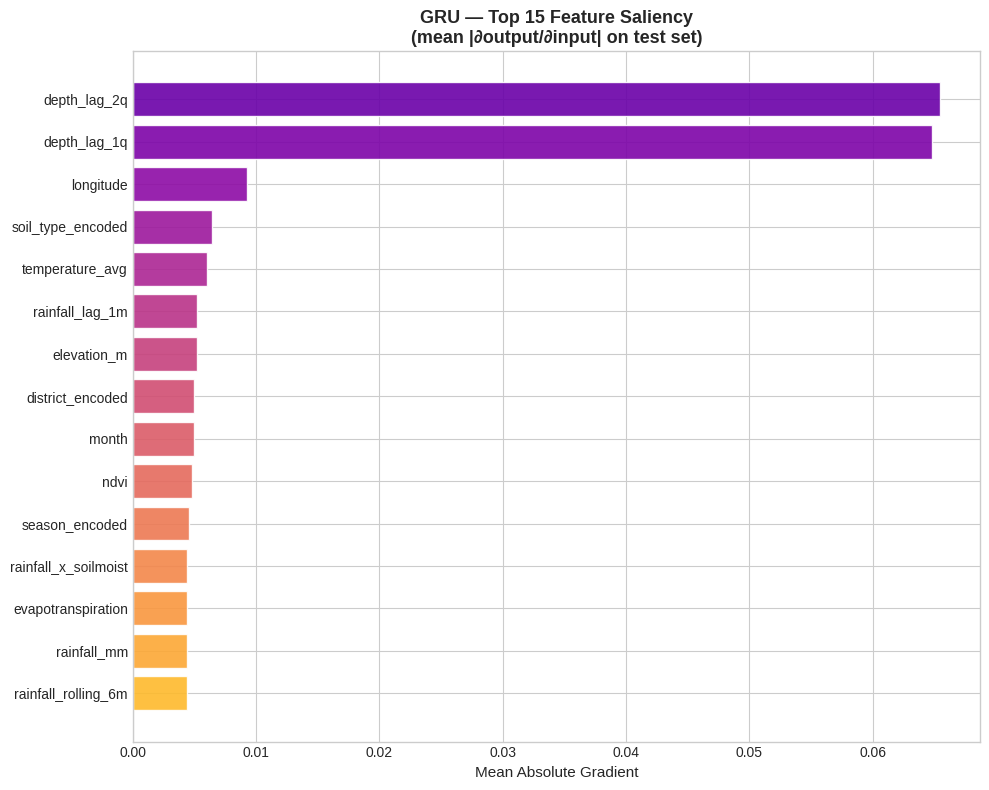

✅ Feature saliency plot saved


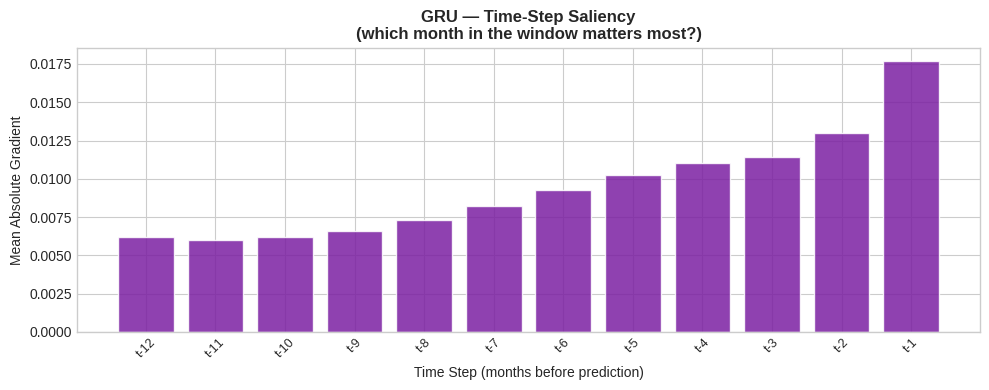

✅ Time-step saliency plot saved


In [19]:

# ============================================================
# STEP 13: GRADIENT-BASED FEATURE IMPORTANCE (Saliency)
# ============================================================

print("🔄 Computing gradient-based feature saliency on test set...")

# Use a sample for speed (1000 random test sequences)
rng_imp = np.random.default_rng(RANDOM_STATE)
n_sample = min(1000, len(Xs_test))
idx_s = rng_imp.choice(len(Xs_test), n_sample, replace=False)
Xs_sample = tf.constant(Xs_test[idx_s], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(Xs_sample)
    preds = gru_final(Xs_sample, training=False)

# Gradient of sum-of-predictions w.r.t. input sequences
grads = tape.gradient(preds, Xs_sample)  # shape: (n_sample, LOOKBACK, n_features)

# Mean absolute gradient across samples and time-steps → (n_features,)
saliency = np.abs(grads.numpy()).mean(axis=(0, 1))
saliency_series = pd.Series(saliency, index=FEATURES).sort_values(ascending=False)

print(f"\n📊 Top 15 Gradient Saliency Scores (test set, n={n_sample} samples):")
print(saliency_series.head(15).to_string())

# ── Feature saliency plot ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(15, len(FEATURES))
sal_top = saliency_series.head(top_n)
colors = plt.cm.plasma(np.linspace(0.2, 0.85, top_n))
ax.barh(range(top_n), sal_top.values[::-1], color=colors[::-1], edgecolor="white", alpha=0.9)
ax.set_yticks(range(top_n))
ax.set_yticklabels(sal_top.index[::-1], fontsize=10)
ax.set_title(f"GRU — Top {top_n} Feature Saliency\n(mean |∂output/∂input| on test set)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Mean Absolute Gradient", fontsize=11)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_feature_saliency.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Feature saliency plot saved")

# ── Time-step saliency (which step in the lookback window matters most?) ─
timestep_saliency = np.abs(grads.numpy()).mean(axis=(0, 2))  # (LOOKBACK,)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, LOOKBACK + 1), timestep_saliency,
       color="#7B1FA2", edgecolor="white", alpha=0.85)
ax.set_xticks(range(1, LOOKBACK + 1))
ax.set_xticklabels([f"t-{LOOKBACK-i}" for i in range(LOOKBACK)], rotation=45, fontsize=9)
ax.set_xlabel("Time Step (months before prediction)")
ax.set_ylabel("Mean Absolute Gradient")
ax.set_title("GRU — Time-Step Saliency\n(which month in the window matters most?)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_timestep_saliency.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Time-step saliency plot saved")


---
## 📊 Step 14 — Walk-Forward Cross-Validation

> Standard k-fold CV cannot be used for temporal data.
> **Walk-forward CV**: train on [2015, T], validate on [T+1 year] for T = 2020..2024.

📊 Walk-forward CV — 3 folds (light model, 50 epochs max)

Fold        Train rows     Val rows |       R²    RMSE(m)
-------------------------------------------------------
  1       rows 0→46117 rows 46117→54502 |   0.8659      14.48
  2       rows 0→54502 rows 54502→62887 |   0.9589       8.51
  3       rows 0→62887 rows 62887→71272 |   0.9157      17.25

  Walk-forward CV R²   mean±std = 0.9135 ± 0.0465
  Walk-forward CV RMSE mean±std = 13.41 ± 4.47 m


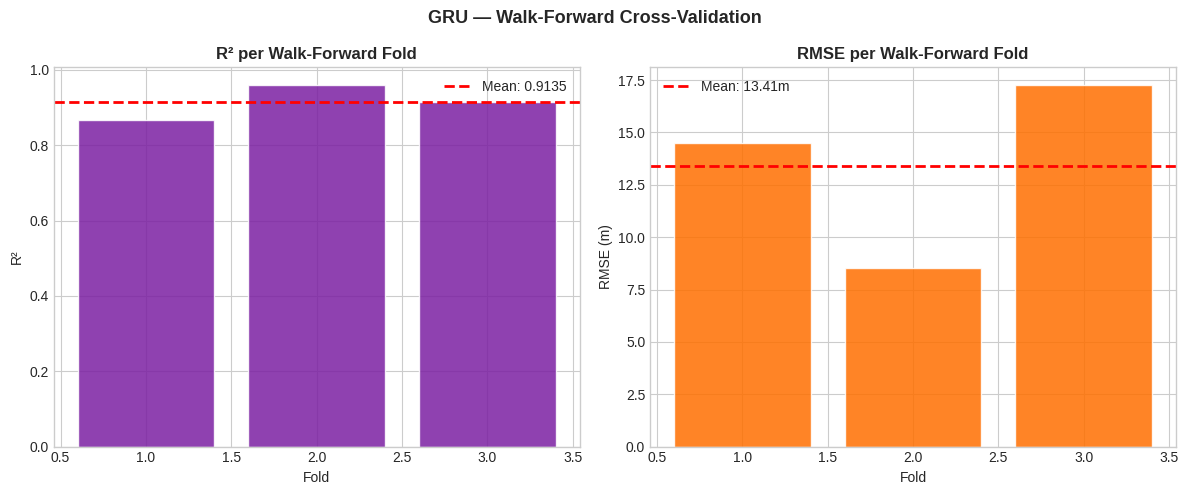

✅ Walk-forward CV plot saved


In [20]:

# ============================================================
# STEP 14: WALK-FORWARD CROSS-VALIDATION
# ============================================================
# No date/year column in dataset → folds defined by row-index proportions.
# Each fold trains on first P% of data, validates on next ~10%.

n_total = len(df)
wf_folds_def = [
    (int(n_total * 0.55), int(n_total * 0.65)),   # fold 1
    (int(n_total * 0.65), int(n_total * 0.75)),   # fold 2
    (int(n_total * 0.75), int(n_total * 0.85)),   # fold 3
]

wf_results = []

print(f"📊 Walk-forward CV — {len(wf_folds_def)} folds (light model, 50 epochs max)\n")
print(f"{'Fold':<6} {'Train rows':>15} {'Val rows':>12} | {'R²':>8} {'RMSE(m)':>10}")
print("-" * 55)

for fold_i, (tr_end, val_end_i) in enumerate(wf_folds_def):
    wf_train_mask = df.index < tr_end
    wf_val_mask   = (df.index >= tr_end) & (df.index < val_end_i)

    Xwf_tr_raw  = X[wf_train_mask]
    Xwf_val_raw = X[wf_val_mask]
    ywf_tr      = y[wf_train_mask]
    ywf_val     = y[wf_val_mask]
    ywf_val_raw = y_raw[wf_val_mask]

    # Fit scaler only on fold's training set — no leakage
    sc_fold = StandardScaler()
    Xwf_tr_sc  = sc_fold.fit_transform(Xwf_tr_raw)
    Xwf_val_sc = sc_fold.transform(Xwf_val_raw)

    # Build sequences per fold
    Xwf_all_sc  = np.concatenate([Xwf_tr_sc,  Xwf_val_sc])
    ywf_all     = np.concatenate([ywf_tr,      ywf_val])
    ywf_all_raw = np.concatenate([y_raw[wf_train_mask], ywf_val_raw])

    Xwf_seq, ywf_seq, ywf_seq_raw = make_sequences(Xwf_all_sc, ywf_all, ywf_all_raw, LOOKBACK)

    n_tr_seq  = max(0, wf_train_mask.sum() - LOOKBACK)
    Xwf_tr_s  = Xwf_seq[:n_tr_seq]
    ywf_tr_s  = ywf_seq[:n_tr_seq]
    Xwf_val_s = Xwf_seq[n_tr_seq:]
    ywf_val_s_raw = ywf_seq_raw[n_tr_seq:]

    if len(Xwf_tr_s) == 0 or len(Xwf_val_s) == 0:
        print(f"  {fold_i+1:<4}  Skipped — not enough data for this fold")
        continue

    # Light model for speed
    tf.random.set_seed(RANDOM_STATE + fold_i + 100)
    gru_wf = build_gru(
        INPUT_SHAPE, gru_units_1=u1_best, gru_units_2=u2_best,
        dense_units=du_best, dropout_rate=dr_best, learning_rate=lr_best,
    )
    cb_wf_es = EarlyStopping(monitor="val_loss", patience=8,
                              restore_best_weights=True, verbose=0)
    gru_wf.fit(
        Xwf_tr_s, ywf_tr_s,
        validation_data=(Xwf_val_s, np.log1p(ywf_val_s_raw.clip(min=0))),
        epochs=50, batch_size=bs_best,
        callbacks=[cb_wf_es], verbose=0,
    )

    y_wf_pred = np.expm1(gru_wf.predict(Xwf_val_s, verbose=0).flatten()).clip(min=0)
    r2_wf   = r2_score(ywf_val_s_raw, y_wf_pred)
    rmse_wf = np.sqrt(mean_squared_error(ywf_val_s_raw, y_wf_pred))

    train_label = f"rows 0→{tr_end}"
    val_label   = f"rows {tr_end}→{val_end_i}"
    print(f"  {fold_i+1:<4} {train_label:>15} {val_label:>12} | {r2_wf:>8.4f} {rmse_wf:>10.2f}")
    wf_results.append(dict(fold=fold_i+1, train_end=tr_end, val_end=val_end_i,
                           R2=r2_wf, RMSE=rmse_wf))
    del gru_wf

if wf_results:
    wf_df = pd.DataFrame(wf_results)
    print("=" * 55)
    print(f"\n  Walk-forward CV R²   mean±std = "
          f"{wf_df['R2'].mean():.4f} ± {wf_df['R2'].std():.4f}")
    print(f"  Walk-forward CV RMSE mean±std = "
          f"{wf_df['RMSE'].mean():.2f} ± {wf_df['RMSE'].std():.2f} m")

    # ── Plot ──────────────────────────────────────────────
    folds_x = wf_df["fold"].values
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(folds_x, wf_df["R2"], color="#7B1FA2", alpha=0.85, edgecolor="white")
    axes[0].axhline(wf_df["R2"].mean(), color="red", linewidth=2, linestyle="--",
                    label=f"Mean: {wf_df['R2'].mean():.4f}")
    axes[0].set_title("R² per Walk-Forward Fold", fontweight="bold")
    axes[0].set_xlabel("Fold"); axes[0].set_ylabel("R²"); axes[0].legend()

    axes[1].bar(folds_x, wf_df["RMSE"], color="#FF6F00", alpha=0.85, edgecolor="white")
    axes[1].axhline(wf_df["RMSE"].mean(), color="red", linewidth=2, linestyle="--",
                    label=f"Mean: {wf_df['RMSE'].mean():.2f}m")
    axes[1].set_title("RMSE per Walk-Forward Fold", fontweight="bold")
    axes[1].set_xlabel("Fold"); axes[1].set_ylabel("RMSE (m)"); axes[1].legend()

    plt.suptitle("GRU — Walk-Forward Cross-Validation", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/08_walkforward_cv.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Walk-forward CV plot saved")
else:
    wf_df = pd.DataFrame(columns=["fold", "R2", "RMSE"])
    print("⚠️  No walk-forward folds completed.")


---
## 🚨 Step 15 — Risk Classification from Predictions

Convert continuous depth predictions to 4-level risk alerts.

| Level | Depth Range | Meaning |
|---|---|---|
| 🟢 **SAFE** | < 30 m | Adequate groundwater |
| 🟡 **WARNING** | 30 – 100 m | Monitor closely |
| 🟠 **CRITICAL** | 100 – 200 m | Activate conservation |
| 🔴 **EXTREME** | > 200 m | Emergency intervention |

  RISK CLASSIFICATION RESULTS (Test Set)

📊 Risk Classification Accuracy: 83.7%

📊 Classification Report:
              precision    recall  f1-score   support

        SAFE       0.96      0.89      0.93      3118
     WARNING       0.88      0.78      0.83      3541
    CRITICAL       0.69      0.97      0.80      2687
     EXTREME       0.93      0.57      0.70      1136

    accuracy                           0.84     10482
   macro avg       0.87      0.80      0.81     10482
weighted avg       0.86      0.84      0.84     10482



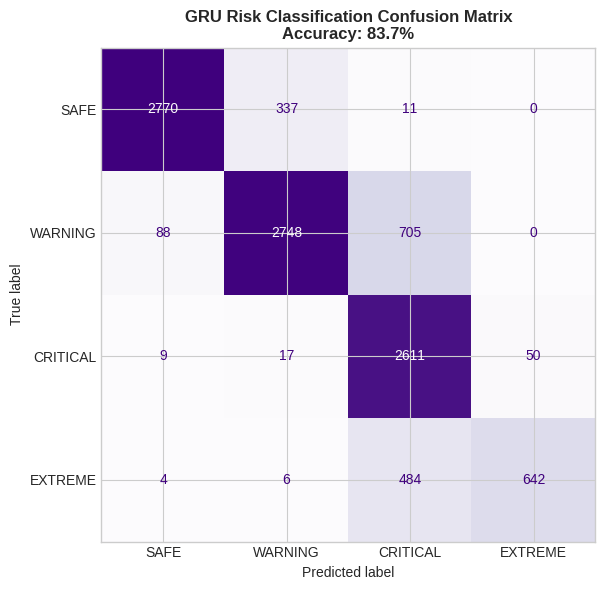

✅ Confusion matrix saved

📊 Predicted Risk Level Distribution (Test set):
   CRITICAL  : 3,811  (36.4%)
   EXTREME   :   692  (6.6%)
   SAFE      : 2,871  (27.4%)


In [21]:

# ============================================================
# STEP 15: RISK CLASSIFICATION
# ============================================================

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay


def classify_risk(depth_m):
    """Map depth (metres) to 4-level risk category."""
    if   depth_m < 30:   return "SAFE"
    elif depth_m < 100:  return "WARNING"
    elif depth_m < 200:  return "CRITICAL"
    else:                return "EXTREME"


y_true_risk = np.array([classify_risk(d) for d in y_true_test])
y_pred_risk = np.array([classify_risk(d) for d in y_pred_test])

acc = accuracy_score(y_true_risk, y_pred_risk)
print("=" * 60)
print("  RISK CLASSIFICATION RESULTS (Test Set)")
print("=" * 60)
print(f"\n📊 Risk Classification Accuracy: {acc*100:.1f}%")
print("\n📊 Classification Report:")
print(classification_report(y_true_risk, y_pred_risk,
      labels=["SAFE", "WARNING", "CRITICAL", "EXTREME"]))

# ── Confusion matrix ───────────────────────────────────────
labels_order = ["SAFE", "WARNING", "CRITICAL", "EXTREME"]
cm = confusion_matrix(y_true_risk, y_pred_risk, labels=labels_order)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, colorbar=False, cmap="Purples")
ax.set_title(f"GRU Risk Classification Confusion Matrix\nAccuracy: {acc*100:.1f}%",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_risk_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix saved")

# ── Distribution of predicted risk levels ─────────────────
unique, counts = np.unique(y_pred_risk, return_counts=True)
print("\n📊 Predicted Risk Level Distribution (Test set):")
for label, count in zip(unique, counts):
    print(f"   {label:<10}: {count:5,}  ({count/len(y_pred_risk)*100:.1f}%)")


---
## 💾 Step 16 — Save Model & Artifacts (PKL Format)

> **How the PKL works:**
> Keras models are not natively picklable, so we use a lightweight **`GRUModelPackage`** wrapper:
> - Stores model architecture (JSON) + weights (numpy arrays) — both pickle-safe
> - Stores the `StandardScaler`, `LabelEncoder`, feature list, and `LOOKBACK`
> - A `get_model()` method reconstructs the full Keras model from the stored config + weights

In [22]:

# ============================================================
# STEP 16: SAVE MODEL & ALL ARTIFACTS — PKL FORMAT
# ============================================================

PKL_PATH      = f"{MODEL_DIR}/gru_temporal.pkl"
METRICS_PATH  = f"{OUTPUT_DIR}/gru_metrics.json"
PARAMS_PATH   = f"{OUTPUT_DIR}/gru_best_params.json"
SALIENCY_PATH = f"{OUTPUT_DIR}/gru_feature_saliency.csv"


# ── PKL-safe wrapper class ─────────────────────────────────
class GRUModelPackage:
    """
    Pickle-safe container for the trained GRU model and all inference artefacts.

    Attributes
    ----------
    model_config_json : str
        Keras model architecture as JSON string.
    model_weights : list of np.ndarray
        Trained model weights (one array per layer).
    scaler : StandardScaler
        Feature scaler fitted on training data.
    features : list of str
        Ordered feature names matching the model-ready dataset.
    lookback : int
        Sequence window length in months.
    hyperparams : dict
        Best hyperparameters found during grid search.
    metrics : dict
        Final model metrics on train/val/test splits.

    Methods
    -------
    get_model() -> tf.keras.Model
        Reconstruct and return a compiled Keras GRU model.
    predict_depth(X_raw_2d) -> np.ndarray
        End-to-end inference: scale → sequence → predict → expm1.
    """

    def __init__(self, model, scaler, features, lookback, hyperparams, metrics):
        self.model_config_json = model.to_json()
        self.model_weights     = model.get_weights()
        self.scaler            = scaler
        self.features          = features
        self.lookback          = lookback
        self.hyperparams       = hyperparams
        self.metrics           = metrics

    def get_model(self):
        """Reconstruct the Keras GRU model from stored config + weights."""
        from tensorflow.keras.models import model_from_json
        model = model_from_json(self.model_config_json)
        model.set_weights(self.model_weights)
        model.compile(optimizer="adam", loss="mse", metrics=["mae"])
        return model

    def predict_depth(self, X_raw_2d: np.ndarray) -> np.ndarray:
        """
        Full inference pipeline.

        Parameters
        ----------
        X_raw_2d : np.ndarray, shape (N, n_features)
            Raw (unscaled) feature matrix for N consecutive time-steps.
            Must contain at least `lookback` rows.

        Returns
        -------
        predictions : np.ndarray, shape (N - lookback,)
            Predicted groundwater depth in metres.
        """
        if X_raw_2d.shape[0] < self.lookback:
            raise ValueError(f"Need at least {self.lookback} rows; got {X_raw_2d.shape[0]}")

        X_sc  = self.scaler.transform(X_raw_2d)
        dummy = np.zeros(X_raw_2d.shape[0])
        Xs, _, _ = make_sequences(X_sc, dummy, dummy, self.lookback)

        model = self.get_model()
        y_log = model.predict(Xs, verbose=0).flatten()
        return np.expm1(y_log).clip(min=0)


# ── Build the package ──────────────────────────────────────
wf_r2_mean   = round(wf_df["R2"].mean(),   4) if len(wf_df) > 0 else None
wf_r2_std    = round(wf_df["R2"].std(),    4) if len(wf_df) > 0 else None
wf_rmse_mean = round(wf_df["RMSE"].mean(), 4) if len(wf_df) > 0 else None

gru_package = GRUModelPackage(
    model       = gru_final,
    scaler      = scaler,
    features    = FEATURES,
    lookback    = LOOKBACK,
    hyperparams = dict(
        gru_units_1=u1_best, gru_units_2=u2_best,
        dense_units=du_best, dropout_rate=dr_best,
        learning_rate=lr_best, batch_size=bs_best,
    ),
    metrics     = dict(
        test_r2   = round(final_test["R2"],   4),
        test_rmse = round(final_test["RMSE"], 4),
        test_mae  = round(final_test["MAE"],  4),
        test_mdape= round(final_test["MdAPE"],4),
        risk_accuracy_pct = round(acc * 100, 1),
    ),
)

# ── Save PKL ───────────────────────────────────────────────
with open(PKL_PATH, "wb") as f:
    pickle.dump(gru_package, f, protocol=pickle.HIGHEST_PROTOCOL)
size_mb = os.path.getsize(PKL_PATH) / (1024 ** 2)
print(f"💾 Model PKL saved → {PKL_PATH}  ({size_mb:.1f} MB)")

# ── Save metrics JSON ──────────────────────────────────────
full_metrics = {
    "model"          : "GRU (Stacked GRU Regressor)",
    "target"         : "depth_mbgl",
    "transform"      : "log1p / expm1",
    "lookback_months": LOOKBACK,
    "features_used"  : len(FEATURES),
    "split"          : "75% train / 12.5% val / 12.5% test (row-index)",
    "architecture"   : {
        "gru_units_1"    : u1_best,
        "gru_units_2"    : u2_best,
        "dense_units"    : du_best,
        "dropout_rate"   : dr_best,
        "learning_rate"  : lr_best,
        "batch_size"     : bs_best,
    },
    "train": {
        "R2"   : round(final_trainval["R2"],   4),
        "RMSE" : round(final_trainval["RMSE"], 4),
        "MAE"  : round(final_trainval["MAE"],  4),
        "MdAPE": round(final_trainval["MdAPE"],4),
    },
    "test": {
        "R2"   : round(final_test["R2"],   4),
        "RMSE" : round(final_test["RMSE"], 4),
        "MAE"  : round(final_test["MAE"],  4),
        "MdAPE": round(final_test["MdAPE"],4),
        "risk_accuracy_pct": round(acc * 100, 1),
    },
    "wf_cv_r2_mean"  : wf_r2_mean,
    "wf_cv_r2_std"   : wf_r2_std,
    "wf_cv_rmse_mean": wf_rmse_mean,
}

with open(METRICS_PATH, "w") as f:
    json.dump(full_metrics, f, indent=2)
print(f"📊 Metrics saved  → {METRICS_PATH}")

# ── Save best params JSON ──────────────────────────────────
bp_save = {
    "gru_units_1" : u1_best,
    "gru_units_2" : u2_best,
    "dense_units" : du_best,
    "dropout_rate": dr_best,
    "learning_rate": lr_best,
    "batch_size"  : bs_best,
    "lookback"    : LOOKBACK,
}
with open(PARAMS_PATH, "w") as f:
    json.dump(bp_save, f, indent=2)
print(f"⚙️  Params saved   → {PARAMS_PATH}")

# ── Save saliency CSV ──────────────────────────────────────
sal_df = pd.DataFrame({
    "feature"  : FEATURES,
    "saliency" : saliency,
}).sort_values("saliency", ascending=False)
sal_df.to_csv(SALIENCY_PATH, index=False)
print(f"📁 Saliency scores → {SALIENCY_PATH}")

# ── Summary card ───────────────────────────────────────────
print("\n" + "=" * 62)
print("  ✅  GRU TEMPORAL ENGINE — COMPLETE")
print("=" * 62)
print(f"  Model         : Stacked GRU (2 layers)")
print(f"  GRU units     : {u1_best} → {u2_best}")
print(f"  Dense units   : {du_best}")
print(f"  Dropout       : {dr_best}")
print(f"  Lookback      : {LOOKBACK} months")
print(f"  LR            : {lr_best:.0e}  |  Batch: {bs_best}")
if wf_r2_mean is not None:
    print(f"  WF-CV R²      : {wf_r2_mean:.4f} ± {wf_r2_std:.4f}")
print(f"  Test R²       : {final_test['R2']:.4f}")
print(f"  Test RMSE     : {final_test['RMSE']:.2f} m")
print(f"  Test MAE      : {final_test['MAE']:.2f} m")
print(f"  Test MdAPE    : {final_test['MdAPE']:.2f}%")
print(f"  Risk Acc.     : {acc*100:.1f}%")
print("=" * 62)


💾 Model PKL saved → /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/gru_temporal.pkl  (1.4 MB)
📊 Metrics saved  → /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/outputs/gru/gru_metrics.json
⚙️  Params saved   → /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/outputs/gru/gru_best_params.json
📁 Saliency scores → /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/outputs/gru/gru_feature_saliency.csv

  ✅  GRU TEMPORAL ENGINE — COMPLETE
  Model         : Stacked GRU (2 layers)
  GRU units     : 256 → 128
  Dense units   : 64
  Dropout       : 0.2
  Lookback      : 12 months
  LR            : 5e-04  |  Batch: 64
  WF-CV R²      : 0.9135 ± 0.0465
  Test R²       : 0.9237
  Test RMSE     : 20.35 m
  Test MAE      : 13.57 m
  Test MdAPE    : 17.32%
  Risk Acc.     : 83.7%


---
## 🔮 Step 17 — Inference Demo & PKL Model Loading

Quick sanity check: reload the saved PKL and run a sample end-to-end prediction.

In [23]:

# ============================================================
# STEP 17: INFERENCE DEMO — reload PKL & predict
# ============================================================

# ── Reload model from PKL ──────────────────────────────────
with open(PKL_PATH, "rb") as f:
    pkg_loaded = pickle.load(f)

print(f"✅ GRUModelPackage loaded from {PKL_PATH}")
print(f"   Features stored : {len(pkg_loaded.features)}")
print(f"   Lookback        : {pkg_loaded.lookback} months")
print(f"   GRU units       : {pkg_loaded.hyperparams['gru_units_1']} → "
      f"{pkg_loaded.hyperparams['gru_units_2']}")
print(f"   Test R²  (stored): {pkg_loaded.metrics['test_r2']}")
print(f"   Test RMSE(stored): {pkg_loaded.metrics['test_rmse']} m")

# Reconstruct Keras model from PKL
gru_reloaded = pkg_loaded.get_model()
print(f"\n✅ Keras GRU model reconstructed successfully")
print(f"   Total parameters: {gru_reloaded.count_params():,}")

# ── Quick predict on 5 random test samples ─────────────────
n_demo    = 5
rng_demo  = np.random.default_rng(seed=42)
start_idx = rng_demo.integers(0, max(1, len(X_test) - LOOKBACK - n_demo))
X_demo_raw   = X_test[start_idx : start_idx + LOOKBACK + n_demo]
y_demo_true  = y_test_raw[start_idx + LOOKBACK : start_idx + LOOKBACK + n_demo]

# End-to-end inference via the package
y_demo_pred = pkg_loaded.predict_depth(X_demo_raw)[:n_demo]

print(f"\n{'Sample':<8} {'True (m)':>10} {'Pred (m)':>10} {'Err (m)':>10} "
      f"{'Risk (True)':>14} {'Risk (Pred)':>14}")
print("-" * 72)
for i, (true, pred) in enumerate(zip(y_demo_true, y_demo_pred)):
    err = pred - true
    print(f"{i+1:<8} {true:>10.2f} {pred:>10.2f} {err:>+10.2f} "
          f"{classify_risk(true):>14} {classify_risk(pred):>14}")

print("\n🎉  GRU Temporal Engine notebook complete!")
print(f"    All outputs saved to  {OUTPUT_DIR}")
print(f"    Model PKL saved to    {PKL_PATH}")
print(f"\n    PKL loading snippet (copy-paste ready):")
print("    ─" * 32)
print(f"    import pickle")
print(f"    with open('{PKL_PATH}', 'rb') as f:")
print(f"        gru_pkg = pickle.load(f)")
print(f"    gru_model = gru_pkg.get_model()            # Keras model")
print(f"    preds = gru_pkg.predict_depth(X_raw_2d)    # metres")


✅ GRUModelPackage loaded from /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/gru_temporal.pkl
   Features stored : 25
   Lookback        : 12 months
   GRU units       : 256 → 128
   Test R²  (stored): 0.9237
   Test RMSE(stored): 20.3467 m

✅ Keras GRU model reconstructed successfully
   Total parameters: 375,425

Sample     True (m)   Pred (m)    Err (m)    Risk (True)    Risk (Pred)
------------------------------------------------------------------------
1             47.45      66.32     +18.87        WARNING        WARNING
2             56.29      70.33     +14.04        WARNING        WARNING
3             58.55      72.95     +14.40        WARNING        WARNING
4             60.62      86.45     +25.83        WARNING        WARNING
5             63.94      87.83     +23.89        WARNING        WARNING

🎉  GRU Temporal Engine notebook complete!
    All outputs saved to  /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/outputs/gru
    Model